# Estimadores e suas propriedades

**Tema:** Estatística › Inferência e Estimação

Um estimador é uma **receita** para transformar dados em um número. Existem
muitas receitas para o mesmo alvo, e elas não são equivalentes.

Neste notebook vamos construir a **distribuição amostral** de vários
estimadores por simulação — e com ela medir viés, variância e erro quadrático
médio de forma direta, sem álgebra.

> **A ideia-chave:** na vida real você tem **uma** amostra e **uma**
> estimativa. Aqui, como simulamos, temos 50.000 amostras — e portanto podemos
> ver a distribuição inteira que, na prática, é invisível. É o único jeito de
> desenvolver intuição sobre o que "erro-padrão" significa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(1789)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. A distribuição amostral, vista de perto

Vamos fixar uma população conhecida e extrair milhares de amostras dela.

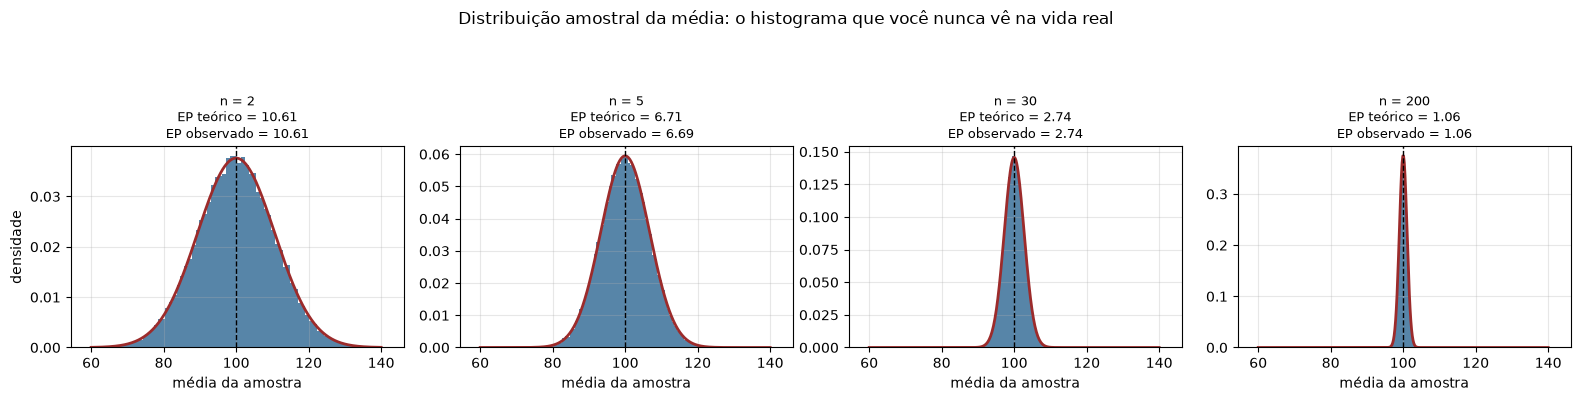

In [2]:
MU_VERDADEIRO, SIGMA_VERDADEIRO = 100.0, 15.0
N_AMOSTRAS = 50_000

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharex=True)
for ax, n in zip(axes, [2, 5, 30, 200]):
    amostras = rng.normal(MU_VERDADEIRO, SIGMA_VERDADEIRO, size=(N_AMOSTRAS, n))
    medias = amostras.mean(axis=1)
    ax.hist(medias, bins=80, density=True, color=AZUL, alpha=0.75, edgecolor="none")
    ep_teorico = SIGMA_VERDADEIRO / np.sqrt(n)
    grade = np.linspace(60, 140, 400)
    ax.plot(grade, stats.norm.pdf(grade, MU_VERDADEIRO, ep_teorico),
            lw=2, color=VERMELHO)
    ax.axvline(MU_VERDADEIRO, ls="--", color="black", lw=1)
    ax.set_title(f"n = {n}\nEP teórico = {ep_teorico:.2f}\n"
                 f"EP observado = {medias.std(ddof=1):.2f}", fontsize=9.5)
    ax.set_xlabel("média da amostra")
axes[0].set_ylabel("densidade")
plt.suptitle("Distribuição amostral da média: o histograma que você nunca vê na vida real",
             y=1.10)
plt.tight_layout()
plt.show()

Três fatos para gravar:

1. A distribuição amostral está **centrada** em $\mu$ — a média é não-viesada.
2. Ela **encolhe** conforme $n$ cresce, na taxa $\sigma/\sqrt{n}$.
3. O erro-padrão **observado** (desvio-padrão das 50.000 médias) bate com o
   **teórico**. O erro-padrão não é uma abstração: é literalmente o
   desvio-padrão deste histograma.

## 2. Viés, variância e EQM medidos diretamente

Vamos comparar cinco estimadores do **centro** de uma distribuição normal.

In [3]:
def avalia_estimadores(gerador, alvo, n, n_amostras=50_000, rotulo=""):
    """Mede viés, variância e EQM de vários estimadores por simulação."""
    amostras = gerador((n_amostras, n))
    estimadores = {
        "Média": amostras.mean(axis=1),
        "Mediana": np.median(amostras, axis=1),
        "Média aparada 20%": stats.trim_mean(amostras, 0.20, axis=1),
        "Ponto médio (min+max)/2": (amostras.min(axis=1) + amostras.max(axis=1)) / 2,
        "Primeira observação": amostras[:, 0],
    }
    linhas = []
    for nome, est in estimadores.items():
        vies = est.mean() - alvo
        var = est.var(ddof=1)
        linhas.append({"estimador": nome, "viés": vies, "variância": var,
                       "EQM": var + vies ** 2,
                       "EQM (direto)": np.mean((est - alvo) ** 2)})
    tab = pd.DataFrame(linhas).set_index("estimador")
    tab["eficiência relativa"] = tab["EQM"].min() / tab["EQM"]
    print(f"\n=== {rotulo} (n={n}) ===")
    print(tab.round(4).to_string())
    return tab, estimadores


tab_normal, est_normal = avalia_estimadores(
    lambda tam: rng.normal(100, 15, tam), 100.0, n=25,
    rotulo="População NORMAL")


=== População NORMAL (n=25) ===
                           viés  variância       EQM  EQM (direto)  eficiência relativa
estimador                                                                              
Média                   -0.0073     9.0336    9.0337        9.0335               1.0000
Mediana                  0.0123    14.0235   14.0237       14.0234               0.6442
Média aparada 20%       -0.0003    10.3172   10.3172       10.3170               0.8756
Ponto médio (min+max)/2 -0.0282    29.6081   29.6089       29.6083               0.3051
Primeira observação     -0.0413   226.4042  226.4059      226.4014               0.0399


Leitura da tabela:

* Todos os estimadores são **não-viesados** (a normal é simétrica, então todos
  acertam o centro na média). Viés não distingue nada aqui.
* A **variância** distingue tudo. A média é a mais eficiente; a "primeira
  observação" tem variância $n = 25$ vezes maior.
* A coluna `EQM (direto)` confirma numericamente a identidade
  $\text{EQM} = \text{Var} + \text{Viés}^2$.

> **A "primeira observação" é um estimador legítimo:** não-viesado e
> consistente? Não — ele **não** é consistente, porque sua variância não cai
> com $n$. Isso mostra que não-viesamento sozinho não vale nada.

## 3. O mesmo experimento com contaminação: o ranking se inverte

In [4]:
def gerador_contaminado(tam, prop=0.05):
    """95% N(100, 15) + 5% N(100, 150) — mesma média, cauda muito mais pesada."""
    limpo = rng.normal(100, 15, tam)
    sujo = rng.normal(100, 150, tam)
    mascara = rng.random(tam) < prop
    return np.where(mascara, sujo, limpo)


tab_cont, _ = avalia_estimadores(gerador_contaminado, 100.0, n=25,
                                 rotulo="População CONTAMINADA (5% de cauda pesada)")


=== População CONTAMINADA (5% de cauda pesada) (n=25) ===
                           viés  variância        EQM  EQM (direto)  eficiência relativa
estimador                                                                               
Média                   -0.0120    53.4414    53.4416       53.4405               0.2149
Mediana                 -0.0066    15.2983    15.2984       15.2981               0.7506
Média aparada 20%        0.0072    11.4834    11.4834       11.4832               1.0000
Ponto médio (min+max)/2 -0.0612  3472.2543  3472.2581     3472.1886               0.0033
Primeira observação     -0.0680  1368.0652  1368.0699     1368.0425               0.0084


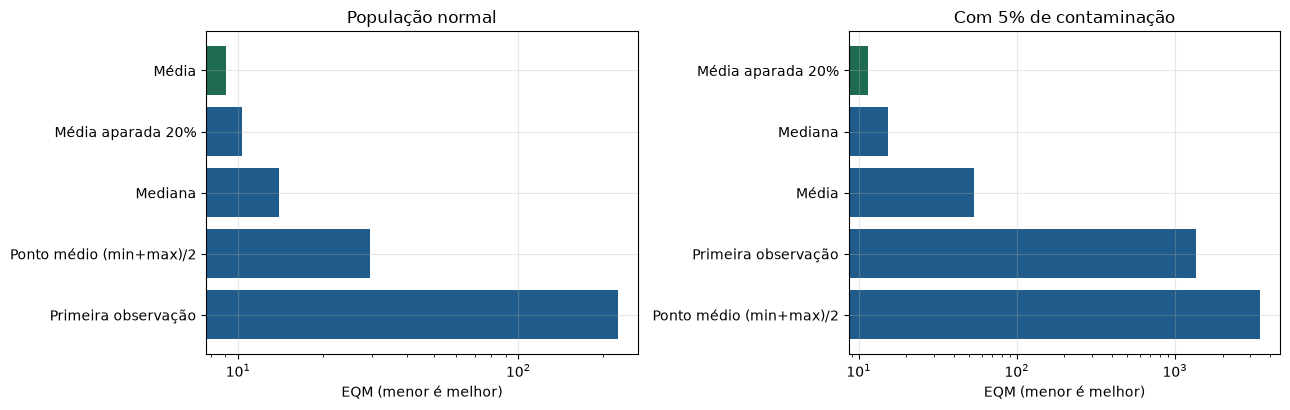

Eficiência da MEDIANA em relação à MÉDIA:
   população normal      : 0.644
   população contaminada : 3.493

(Valor teórico em normalidade pura: 2/π ≈ 0.637 — a mediana 'desperdiça'
 cerca de 36% da informação quando os dados SÃO normais.)


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, tab, titulo in [(ax1, tab_normal, "População normal"),
                        (ax2, tab_cont, "Com 5% de contaminação")]:
    ordem = tab.sort_values("EQM")
    cores = [VERDE if i == 0 else AZUL for i in range(len(ordem))]
    ax.barh(ordem.index[::-1], ordem["EQM"][::-1], color=cores[::-1])
    ax.set_xlabel("EQM (menor é melhor)")
    ax.set_title(titulo)
    ax.set_xscale("log")
plt.tight_layout()
plt.show()

print("Eficiência da MEDIANA em relação à MÉDIA:")
print(f"   população normal      : {tab_normal.loc['Média','EQM'] / tab_normal.loc['Mediana','EQM']:.3f}")
print(f"   população contaminada : {tab_cont.loc['Média','EQM'] / tab_cont.loc['Mediana','EQM']:.3f}")
print("\n(Valor teórico em normalidade pura: 2/π ≈ 0.637 — a mediana 'desperdiça'")
print(" cerca de 36% da informação quando os dados SÃO normais.)")

Esta é a lição central do notebook:

* Em dados **normais**, a média é ~1,57× mais eficiente que a mediana. Usar
  mediana custa caro.
* Em dados com apenas **5% de contaminação**, a ordem se inverte
  dramaticamente.

> **A decisão profissional não é "média ou mediana", é "quanto de contaminação
> eu espero?".** Se você não sabe, a média aparada é o seguro barato: perde
> pouco em normalidade e protege bem contra contaminação.

## 4. Viés que não desaparece: o caso da variância

In [6]:
SIGMA2_VERDADEIRO = 25.0
tamanhos = [2, 3, 5, 10, 20, 50, 100]
linhas = []
for n in tamanhos:
    amostras = rng.normal(0, np.sqrt(SIGMA2_VERDADEIRO), size=(80_000, n))
    v0 = amostras.var(axis=1, ddof=0)   # MLE — viesado
    v1 = amostras.var(axis=1, ddof=1)   # não-viesado (Bessel)
    linhas.append({
        "n": n,
        "E[var ddof=0]": v0.mean(),
        "viés ddof=0": v0.mean() - SIGMA2_VERDADEIRO,
        "viés relativo": (v0.mean() - SIGMA2_VERDADEIRO) / SIGMA2_VERDADEIRO,
        "E[var ddof=1]": v1.mean(),
        "EQM ddof=0": np.mean((v0 - SIGMA2_VERDADEIRO) ** 2),
        "EQM ddof=1": np.mean((v1 - SIGMA2_VERDADEIRO) ** 2),
    })
tab_var = pd.DataFrame(linhas).set_index("n")
print(tab_var.round(4).to_string())

     E[var ddof=0]  viés ddof=0  viés relativo  E[var ddof=1]  EQM ddof=0  EQM ddof=1
n                                                                                    
2          12.5792     -12.4208        -0.4968        25.1584    475.5773   1285.2273
3          16.6197      -8.3803        -0.3352        24.9296    346.8154    622.3234
5          19.9699      -5.0301        -0.2012        24.9624    225.9201    313.4675
10         22.4478      -2.5522        -0.1021        24.9420    119.0070    138.8838
20         23.7594      -1.2406        -0.0496        25.0099     61.2567     66.1691
50         24.5003      -0.4997        -0.0200        25.0003     24.4954     25.2454
100        24.7489      -0.2511        -0.0100        24.9989     12.5378     12.7281


Duas observações que raramente aparecem juntas nos cursos:

1. O viés do `ddof=0` é exatamente $-\sigma^2/n$ — some devagar, mas some.
2. **O estimador viesado tem EQM MENOR.** Olhe as duas últimas colunas: o
   `ddof=0` erra menos, no total, do que o não-viesado.

Isso não é um paradoxo — é a decomposição $\text{EQM} = \text{Var} +
\text{Viés}^2$ em ação. O `ddof=0` troca um pouco de viés por bastante
variância a menos. **Não-viesamento não é o objetivo final; erro pequeno é.**

> **É exatamente esse o argumento a favor da regularização em machine
> learning.** Ridge e Lasso introduzem viés de propósito para reduzir variância
> e, com isso, o erro total. Retomamos isso no tema *Aprendizado
> Supervisionado*.

## 5. Consistência: o que melhora com mais dados e o que não melhora

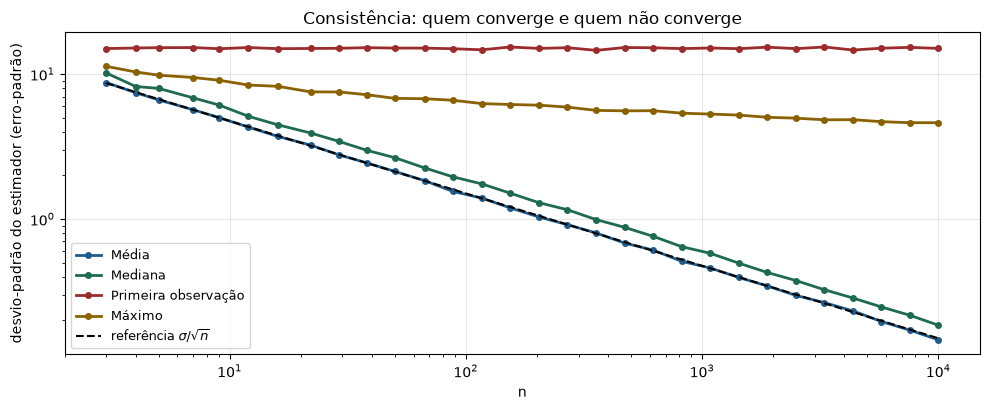

Média e mediana caem paralelas à referência 1/√n  -> consistentes.
A 'primeira observação' é uma linha HORIZONTAL     -> inconsistente.
O máximo nem sequer estima um parâmetro fixo       -> diverge.


In [7]:
tamanhos = np.unique(np.logspace(0.5, 4, 30).astype(int))
convergencia = {"Média": [], "Mediana": [], "Primeira observação": [],
                "Máximo": []}
for n in tamanhos:
    amostras = rng.normal(100, 15, size=(4_000, n))
    convergencia["Média"].append(amostras.mean(axis=1).std(ddof=1))
    convergencia["Mediana"].append(np.median(amostras, axis=1).std(ddof=1))
    convergencia["Primeira observação"].append(amostras[:, 0].std(ddof=1))
    convergencia["Máximo"].append(amostras.max(axis=1).std(ddof=1))

fig, ax = plt.subplots(figsize=(10, 4.2))
for (nome, serie), cor in zip(convergencia.items(), [AZUL, VERDE, VERMELHO, AMBAR]):
    ax.plot(tamanhos, serie, "o-", lw=2, ms=4, label=nome, color=cor)
ax.plot(tamanhos, 15 / np.sqrt(tamanhos), "k--", lw=1.5, label=r"referência $\sigma/\sqrt{n}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n")
ax.set_ylabel("desvio-padrão do estimador (erro-padrão)")
ax.set_title("Consistência: quem converge e quem não converge")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Média e mediana caem paralelas à referência 1/√n  -> consistentes.")
print("A 'primeira observação' é uma linha HORIZONTAL     -> inconsistente.")
print("O máximo nem sequer estima um parâmetro fixo       -> diverge.")

## 6. Informação de Fisher: por onde a precisão entra

A informação de Fisher mede quão "pontuda" é a verossimilhança. Verossimilhança
pontuda = os dados distinguem bem valores próximos do parâmetro = estimativa
precisa.

Para a Bernoulli, $I(p) = \frac{1}{p(1-p)}$. Vamos confirmar que o limite de
Cramér-Rao é atingido.

In [8]:
n = 500
resultados = []
for p_verdadeiro in [0.5, 0.2, 0.05, 0.01]:
    amostras = (rng.random((30_000, n)) < p_verdadeiro)
    p_est = amostras.mean(axis=1)
    var_observada = p_est.var(ddof=1)
    # Limite de Cramér-Rao: 1 / (n · I(p)) = p(1-p)/n
    limite_cr = p_verdadeiro * (1 - p_verdadeiro) / n
    resultados.append({
        "p verdadeiro": p_verdadeiro,
        "I(p) = 1/[p(1-p)]": 1 / (p_verdadeiro * (1 - p_verdadeiro)),
        "variância observada": var_observada,
        "limite de Cramér-Rao": limite_cr,
        "razão obs/limite": var_observada / limite_cr,
    })
pd.DataFrame(resultados).set_index("p verdadeiro").round(6)

,I(p) = 1/[p(1-p)],variância observada,limite de Cramér-Rao,razão obs/limite
p verdadeiro,,,,
0.50,4.000000,0.000501,0.000500,1.002377
0.20,6.250000,0.000316,0.000320,0.988839
0.05,21.052632,0.000095,0.000095,1.004342
0.01,101.010101,0.000019,0.000020,0.981379


A razão observada/limite é ≈ 1,00 em todos os casos: a média amostral **atinge**
o limite de Cramér-Rao para a Bernoulli. É um estimador eficiente — nenhum
estimador não-viesado pode fazer melhor.

Note também a coluna $I(p)$: a informação **explode** conforme $p \to 0$. Isso
parece contraditório, mas é a mesma história da seção 1 do notebook de
distribuições discretas: cada observação carrega muita informação sobre $p$ em
termos *absolutos*, e ainda assim o erro **relativo** a $p$ fica enorme.

## 7. Exercícios

1. Compare os estimadores da seção 2 numa população **uniforme** $U(0, \theta)$
   para estimar $\theta$. Teste: (a) $2\bar{X}$, (b) o máximo, (c) o máximo
   corrigido $\frac{n+1}{n}\max$. Qual tem menor EQM? Este é um caso raro em
   que o máximo é excelente — por quê?
2. Repita a seção 3 variando a proporção de contaminação de 0% a 20%. Encontre
   o **ponto de cruzamento** em que a mediana passa a bater a média.
3. A média aparada tem um parâmetro (a proporção aparada). Faça uma varredura
   de 0% a 45% em dados contaminados e encontre o valor ótimo. Ele depende da
   contaminação?
4. Demonstre numericamente que $s$ (o desvio-padrão amostral) é **viesado**
   mesmo com `ddof=1` — a correção de Bessel torna $s^2$ não-viesado, mas a
   raiz quadrada é uma função côncava e a desigualdade de Jensen ataca.

## Próximo passo

`02-maxima-verossimilhanca.ipynb` — o método por trás de praticamente todo
modelo estatístico e de machine learning que você vai usar.